# Notebook to test and see the implementation of Hierarchical Refinement algorithm in jax

In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn_lr

from src.HiRef import hierarchical_refinement_iterative
from src.partition import low_rank_partition
from src.rank_annealing import optimal_rank_schedule

In [4]:
def create_points(
    rng= jax.random.key(0),       # seed for randomeness
    n: int = 100,       # number of points for X and Y
    d: int = 2,         # dimension vectors in X and Y
    ):
    """
    By default we use uniform distribution for a and b.
    """
    rngs = jax.random.split(rng, 4)
    x = jax.random.normal(rngs[0], (n, d)) + 10
    y = jax.random.normal(rngs[1], (n, d))
    a = jax.random.uniform(rngs[2], (n,))
    b = jax.random.uniform(rngs[3], (n,))
    a = a / jnp.sum(a)
    b = b / jnp.sum(b)
    return x, y, a, b

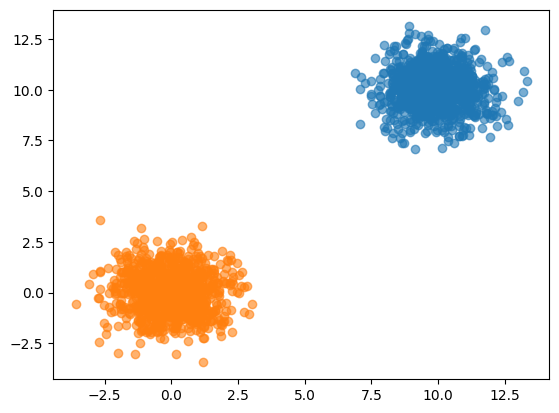

In [10]:
x, y, a, b = create_points( n=1024, d=2)

c_src1 = "#1f77b4"   # bleu foncé
c_tgt1 = "#aec7e8"   # bleu clair

c_src2 = "#ff7f0e"   # orange foncé
c_tgt2 = "#ffbb78"   # orange clair


plt.scatter(x[:, 0], x[:, 1], color=c_src1, label="Source_1", alpha=0.6)
plt.scatter(y[:, 0], y[:, 1], color=c_src2, label="Source_2", alpha=0.6)

#plt.scatter(y1[:, 0], y1[:, 1], color=c_tgt1, label="Target_1", alpha=0.6)
#plt.scatter(y2[:, 0], y2[:, 1], color=c_tgt2, label="Target_2", alpha=0.6)

plt.show()

In [11]:
clusters = hierarchical_refinement_iterative(X=x, Y=y, strategy="rank_annealing")

Optimized rank-annealing schedule: [2, 512]
Optimized rank-annealing schedule: [2, 512]
Stack size: 1

[Depth 0] Processing block of size 1024 with rank 2
Stack size: 2

[Depth 1] Processing block of size 532 with rank 512
Stack size: 189

[Depth 2] Processing block of size 3 with rank 2
Stack size: 190

[Depth 3] Processing block of size 2 with rank 2
Stack size: 190
Stack size: 189
Stack size: 188
Stack size: 187

[Depth 2] Processing block of size 5 with rank 2
Stack size: 187

[Depth 3] Processing block of size 3 with rank 2
Stack size: 187

[Depth 4] Processing block of size 2 with rank 2
Stack size: 187
Stack size: 186

[Depth 2] Processing block of size 2 with rank 2
Stack size: 187
Stack size: 186
Stack size: 185

[Depth 2] Processing block of size 4 with rank 2
Stack size: 186

[Depth 3] Processing block of size 2 with rank 2
Stack size: 187
Stack size: 186
Stack size: 185

[Depth 3] Processing block of size 2 with rank 2
Stack size: 186
Stack size: 185
Stack size: 184

[Depth

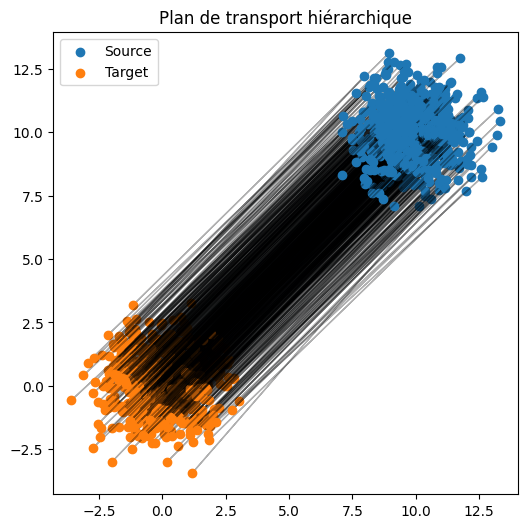

In [12]:
import matplotlib.pyplot as plt

def plot_transport_arrows(clusters):
    plt.figure(figsize=(6, 6))

    for i, (x, y) in enumerate(clusters):
        # x, y sont des vecteurs (shape: (2,))
        plt.arrow(x[0], x[1],
                  y[0] - x[0],
                  y[1] - x[1],
                  head_width=0.05, alpha=0.3, length_includes_head=True)

        # Ajoute la légende une seule fois
        if i == 0:
            plt.scatter(x[0], x[1], c='C0', label='Source')
            plt.scatter(y[0], y[1], c='C1', label='Target')
        else:
            plt.scatter(x[0], x[1], c='C0')
            plt.scatter(y[0], y[1], c='C1')

    plt.legend()
    plt.title("Plan de transport hiérarchique")
    plt.axis("equal")
    plt.show()
    
plot_transport_arrows(clusters)